# Optimierte Gaußpuls-Sequenz

Dieses Notebook erstellt eine Pulseq-Sequenzdatei mit einem optimierten Gaußpuls. Der optimierte Puls wird aus den Ergebnissen der Gaußpuls-Optimierung geladen und mit der `make_arbitrary_rf`-Funktion von pypulseq in eine Sequenz integriert.

Der grundlegende Ablauf ist:
1. Laden des optimierten Pulses aus dem gespeicherten Checkpoint
2. Exportieren des Pulses für die weitere Verwendung
3. Erstellen einer Sequenzdatei ähnlich zu gauss_pulse_seq.ipynb, aber mit dem optimierten Puls

In [1]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import pypulseq as pp

# Erweiterte Imports für die Verwendung von make_arbitrary_rf
from bmc.utils.seq.write import write_seq

## 1. Laden des optimierten Pulses aus dem Checkpoint

Zunächst müssen wir den optimierten Puls aus dem gespeicherten Checkpoint laden.

In [2]:
# Pfad zum besten Checkpoint
wdir = Path().resolve().parent
# Korrigierter Pfad zum Checkpoint
checkpoint_dir = wdir / "bmc" / "optimize" / "gauss_optimization" / "checkpoints" / "sinc_30seq"
checkpoint_path = checkpoint_dir / "best_checkpoint.pt"
# checkpoint_dir = wdir / "bmc" / "optimize" / "gauss_optimization" / "checkpoints" / "gauss_50seq"
# checkpoint_path = checkpoint_dir / "best_checkpoint.pt"

# Überprüfen, ob der Checkpoint existiert
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint-Datei {checkpoint_path} wurde nicht gefunden.")

# Laden des Checkpoints
checkpoint = torch.load(checkpoint_path)
print(f"Checkpoint von Epoche {checkpoint.get('epoch', 'unbekannt')} geladen")
print("Typ des Checkpoints:", type(checkpoint))

t_pulse = 2e-3  # Pulsdauer in Sekunden

if 'rf_parameters' in checkpoint:
    # In gauss_optimization.ipynb werden RF-Parameter als Liste von [amp, phase] Paaren gespeichert
    rf_params = checkpoint['rf_parameters']
    print(f"RF-Parameter gefunden. Typ: {type(rf_params)}")
    
    # Wähle den ersten RF-Puls (erstes Element in der Liste)
    if isinstance(rf_params, list) and len(rf_params) > 0:
        first_pulse = rf_params[0]
        if isinstance(first_pulse, list) and len(first_pulse) > 0:
            # Das erste Element ist die Amplitude des Pulses
            amp = first_pulse[0]
            if isinstance(amp, torch.Tensor):
                optimized_pulse_array = amp.detach().cpu().numpy()
                pulse_dt = t_pulse / len(optimized_pulse_array)
                print(f"Optimierter Puls erfolgreich geladen. Form: {optimized_pulse_array.shape}")
                print(f"end=time: {t_pulse:.2f} s, dt: {pulse_dt:.2e} s")
            else:
                print(f"Unerwarteter Typ für Amplitude: {type(amp)}")
        else:
            print(f"Unerwartete Struktur für den ersten Puls: {type(first_pulse)}")
    else:
        print(f"Unerwartete Struktur für rf_parameters: {type(rf_params)}")

Checkpoint von Epoche 499 geladen
Typ des Checkpoints: <class 'dict'>
RF-Parameter gefunden. Typ: <class 'list'>
Optimierter Puls erfolgreich geladen. Form: (286,)
end=time: 0.00 s, dt: 6.99e-06 s


## 2. Visualisieren und Exportieren des optimierten Pulses

Wir visualisieren den optimierten Puls und exportieren ihn dann für die Verwendung mit `make_arbitrary_rf`.

Optimierter Puls mit dt=6.993006993006993e-06s unter /Users/danielmiksch/JupyterLab/optim/bmc/utils/pulses/optimized_gauss_pulse.npz gespeichert
Optimierter Puls (nur Daten) unter /Users/danielmiksch/JupyterLab/optim/bmc/utils/pulses/optimized_gauss_pulse.npy gespeichert


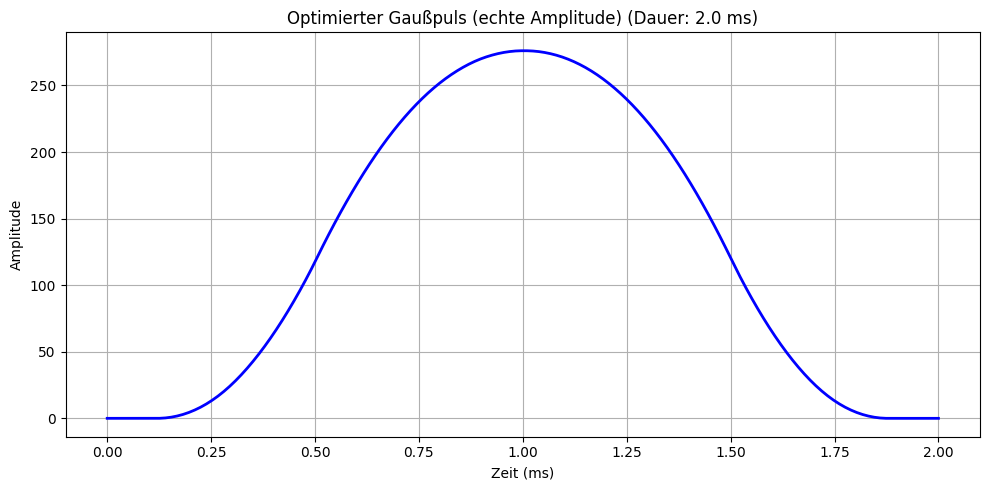

In [3]:
# Visualisieren des optimierten Pulses
def visualize_pulse(pulse_waveform, title="Optimierter Gaußpuls"):
    """
    Visualisiert einen RF-Puls.
    
    Args:
        pulse_waveform: Pulsform (Amplituden)
        title: Titel für den Plot
    """
    # Zeitachse von 0 bis 2 ms berechnen
    time_axis = np.linspace(0, t_pulse*1000, len(pulse_waveform))  # Umrechnung in ms
    
    plt.figure(figsize=(10, 5))
    plt.plot(time_axis, pulse_waveform, 'b-', linewidth=2)
    plt.title(f"{title} (Dauer: {t_pulse*1000:.1f} ms)")
    plt.xlabel('Zeit (ms)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()

# Überprüfe die Form des Arrays und reshape wenn nötig (z.B. aus 2D-Array ein 1D-Array machen)
if optimized_pulse_array.ndim > 1:
    print(f"Puls ist {optimized_pulse_array.ndim}-dimensional mit Form {optimized_pulse_array.shape}, flache ihn ab...")
    # Versuchen wir, eine vernünftige Dimension zu finden
    if optimized_pulse_array.shape[0] == 1:  # Wenn es [1, N] ist
        optimized_pulse_array = optimized_pulse_array[0]
    elif optimized_pulse_array.shape[1] == 1:  # Wenn es [N, 1] ist
        optimized_pulse_array = optimized_pulse_array[:, 0]
    else:
        # Falls keine einzelne Dimension gefunden wird, nehmen wir die erste Dimension
        optimized_pulse_array = optimized_pulse_array[0]

# Für die Visualisierung den Puls mit der korrekten Abtastzeit zeigen
visualize_pulse(optimized_pulse_array, title="Optimierter Gaußpuls (echte Amplitude)")

# Exportieren des Pulses als NumPy-Array für die weitere Verwendung
pulses_dir = wdir / "bmc" / "utils" / "pulses"
pulses_dir.mkdir(exist_ok=True, parents=True)

# Auch die Abtastzeit (dt) mit dem Puls zusammen speichern
pulse_info = {
    'pulse': optimized_pulse_array,
    'dt': pulse_dt
}

# Speichern als .npz Format, um mehrere Arrays zu speichern
pulse_file_path = pulses_dir / "optimized_gauss_pulse.npz"
np.savez(pulse_file_path, **pulse_info)
print(f"Optimierter Puls mit dt={pulse_dt}s unter {pulse_file_path} gespeichert")

# Auch als .npy für Kompatibilität speichern
pulse_file_path_npy = pulses_dir / "optimized_gauss_pulse.npy"
np.save(pulse_file_path_npy, optimized_pulse_array)
print(f"Optimierter Puls (nur Daten) unter {pulse_file_path_npy} gespeichert")

## 3. Erstellen der Sequenz mit dem optimierten Puls

Basierend auf gauss_pulse_seq.ipynb erstellen wir nun eine Sequenz mit dem optimierten Puls.

In [4]:
# Basiseinstellungen für die Sequenz
folder = wdir / "seq_lib"

sys = pp.Opts(
    max_grad=500,
    grad_unit="mT/m",
    max_slew=1e9,
    slew_unit="T/m/s",
    rf_ringdown_time=0,
    rf_dead_time=0,
    rf_raster_time=1e-6,
    gamma=42576400,
    grad_raster_time=1e-6,
)

# Allgemeine Einstellungen
AUTHOR = "DANIEL MIKSCH"
FLAG_PLOT_SEQUENCE = True  # Sequenz plotten?
FLAG_CHECK_TIMING = True   # Timing-Check am Ende der Sequenz durchführen?
FLAG_POST_PREP_SPOIL = True  # Spoiler nach Präparationsblock hinzufügen?

defs: dict = {}

In [5]:
# Definitionen aus dem Original-Notebook
seqid = "sinc_opt"  # Dateiname für die optimierte Version

defs["a"] = 50  # alpha in degrees
defs["b0"] = 17  # B0 [T]
defs["m0_offset"] = 0  # m0 offset [ppm]
defs["n_ETM"] = 1  # number of ETMs

# RF-Einstellungen
flip_angle_90 = np.radians(defs['a'])
flip_angle_180 = np.radians(180)
t_pulse = 2e-3  # Pulsdauer in Sekunden (aus dem Original-Notebook)
# Delay-Einstellungen
delay_inter_etm = pp.make_delay(20e-3)
delay_exchange = pp.make_delay(80e-3)
pseudo_delay = pp.make_delay(1e-3)

# ADC
pseudo_adc = pp.make_adc(num_samples=1, duration=1e-3)

# Weitere Berechnungen
defs["offsets_ppm"] = np.array([defs["m0_offset"]])
defs["num_meas"] = defs["offsets_ppm"].size  # Anzahl der Wiederholungen
defs["seq_id_string"] = seqid  # Eindeutige Sequenz-ID
seq_filename = defs["seq_id_string"] + ".seq"
GAMMA_HZ = sys.gamma * 1e-6
defs["freq"] = defs["b0"] * GAMMA_HZ  # Larmor-Frequenz [Hz]

## Verwenden von make_arbitrary_rf

Im Gegensatz zum Original-Notebook verwenden wir hier `make_arbitrary_rf` statt `make_gauss_pulse`, um unseren optimierten Puls einzusetzen.

In [6]:
# Laden des optimierten Pulses
try:
    # Versuchen, die .npz-Datei zu laden, die auch dt enthält
    pulse_data = np.load(pulse_file_path)
    optimized_pulse_array = pulse_data['pulse']
    # Wenn dt in den gespeicherten Daten vorhanden ist, verwenden wir es
    if 'dt' in pulse_data:
        loaded_dt = float(pulse_data['dt'])
        print(f"Abtastzeit aus gespeichertem Puls geladen: {loaded_dt} s")
        # Wir überprüfen, ob die geladene dt mit unserer übereinstimmt
        if abs(loaded_dt - pulse_dt) > 1e-10:
            print(f"WARNUNG: Geladene dt ({loaded_dt}) unterscheidet sich von der aus dem Checkpoint ({pulse_dt})!")
            print(f"Verwende die geladene dt ({loaded_dt}) für die RF-Puls-Erzeugung.")
            pulse_dt = loaded_dt
except Exception as e:
    # Falls die .npz-Datei nicht geladen werden kann, versuchen wir .npy
    print(f"Konnte .npz-Datei nicht laden ({e}), versuche .npy...")
    optimized_pulse_array = np.load(pulse_file_path_npy)
    print("Optimierter Puls aus .npy geladen, verwende dt aus Checkpoint")

# Importieren der make_arbitrary_rf Funktion
from pypulseq import make_arbitrary_rf

rf_90_opt = make_arbitrary_rf(
    signal=optimized_pulse_array,  # Amplitudenwerte des optimierten Pulses
    flip_angle=flip_angle_90,      # Flipwinkel aus den Definitionen
    system=sys,                    # System-Einstellungen
    dwell=pulse_dt,                # Wichtig: Korrekte Abtastzeit übergeben!
    time_bw_product=None,          # Für arbitrary RF nicht benötigt
    no_signal_scaling=True,        # Wichtig: Keine Skalierung der Signalwerte
    freq_offset=0,                 # Keine Frequenzverschiebung
    phase_offset=0,                # Keine Phasenverschiebung
    return_gz=False                # Kein Gradient zurückgeben
)

# Zum Vergleich: Erstellen eines Standard-Gaußpulses mit denselben Parametern
rf_90_original = pp.make_gauss_pulse(
    flip_angle=flip_angle_90,
    system=sys,
    duration=t_pulse,
    center_pos=0.5,
    freq_offset=0,
    phase_offset=0,
    return_gz=False
)

# Informationen über die Pulse ausgeben
print(f"Optimierter Puls: {len(rf_90_opt.signal)} Samples")
print(f"Original Gaußpuls: {len(rf_90_original.signal)} Samples")

Abtastzeit aus gespeichertem Puls geladen: 6.993006993006993e-06 s
Optimierter Puls: 286 Samples
Original Gaußpuls: 2000 Samples


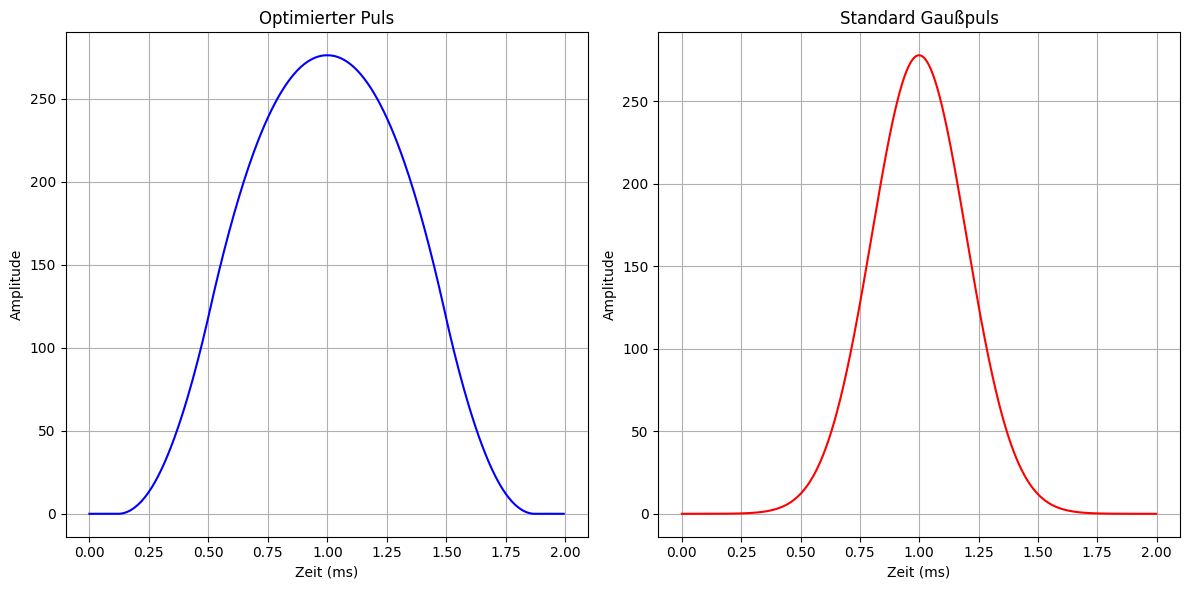

In [7]:
# Visualisieren beider Pulse zum Vergleich
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(np.arange(len(rf_90_opt.signal)) * pulse_dt * 1000, np.abs(rf_90_opt.signal), 'b-')
plt.title('Optimierter Puls')
plt.xlabel('Zeit (ms)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(np.arange(len(rf_90_original.signal)) * 1e-6 * 1000, np.abs(rf_90_original.signal), 'r-')
plt.title('Standard Gaußpuls')
plt.xlabel('Zeit (ms)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()

## Erstellen der Sequenz

Nun erstellen wir die Sequenz mit dem optimierten Puls, ähnlich wie in gauss_pulse_seq.ipynb.

In [8]:
# Sequenz erstellen
seq = pp.Sequence()
offsets_hz = defs["offsets_ppm"] * defs["freq"]  # Umrechnung von ppm zu Hz

# Frequenzversatz für den RF-Puls setzen
rf_90_opt.freq_offset = offsets_hz[0]

# Sequenzblöcke hinzufügen
for i in range(defs["n_ETM"]):
    seq.add_block(pseudo_delay)
    seq.add_block(rf_90_opt)  # Optimierten Puls verwenden
    
seq.add_block(pseudo_adc)


Timing check passed successfully


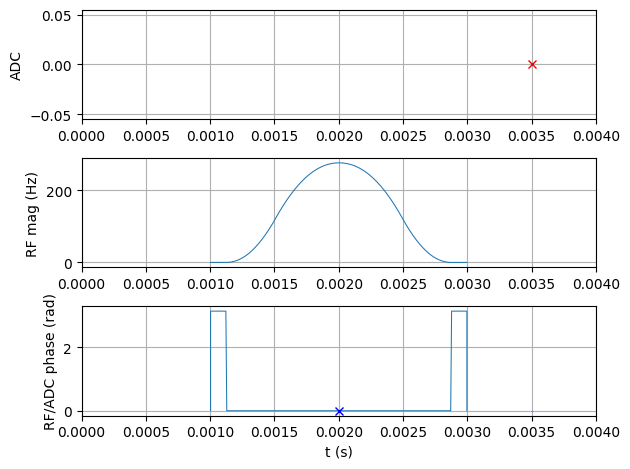

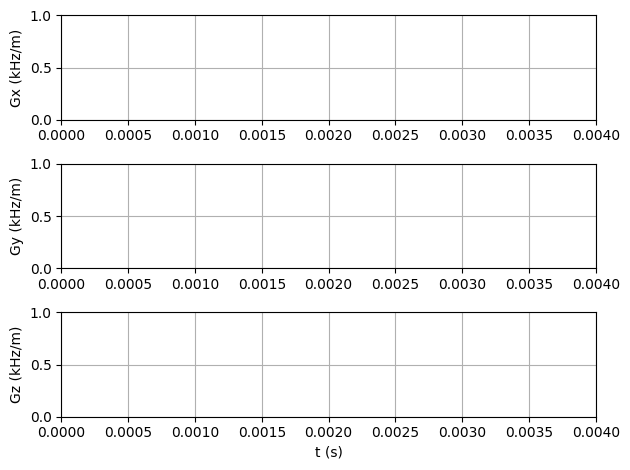

In [9]:
# Timing-Check und Sequenz plotten
if FLAG_CHECK_TIMING:
    ok, error_report = seq.check_timing()
if ok:
    print("\nTiming check passed successfully")
else:
    print("\nTiming check failed! Error listing follows\n")
    print(error_report)

if FLAG_PLOT_SEQUENCE:
    seq.plot()

In [10]:
# Sequenzdatei schreiben
write_seq(seq=seq, seq_defs=defs, filename=folder / seq_filename, author=AUTHOR, use_matlab_names=True)
print(f"Sequenz wurde unter {folder / seq_filename} gespeichert")

Sequenz wurde unter /Users/danielmiksch/JupyterLab/optim/seq_lib/sinc_opt.seq gespeichert


## Vergleich: Optimierter vs. Original-Gaußpuls

Zum Abschluss vergleichen wir die Signalstärke des optimierten Pulses mit der des Original-Gaußpulses.

In [11]:
# Wenn in den Metadaten verfügbar, informieren wir über die Verbesserung
if metadata_path.exists():
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    signal_value = metadata.get('signal')
    if signal_value:
        print(f"Signal des optimierten Pulses laut Optimierung: {signal_value:.6f}")
        
        # Zusätzliche Informationen aus dem Checkpoint
        original_signal = checkpoint.get('original_signal', None)
        if original_signal:
            improvement = (signal_value - original_signal) / abs(original_signal) * 100
            print(f"Ursprünglicher Gaußpuls Signal: {original_signal:.6f}")
            print(f"Verbesserung durch Optimierung: {improvement:.2f}%")

NameError: name 'metadata_path' is not defined

## Zusammenfassung

In diesem Notebook haben wir:
1. Den optimierten Gaußpuls aus dem gespeicherten Checkpoint geladen
2. Den Puls als NumPy-Array für die weitere Verwendung exportiert
3. Eine Sequenzdatei mit dem optimierten Puls unter Verwendung von `make_arbitrary_rf` erstellt
4. Die Sequenz als Pulseq-Datei (.seq) gespeichert

Die optimierte Sequenzdatei kann nun für weitere Simulationen oder Experimente verwendet werden.